In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

df = pd.read_csv("final_cleaned_dataset.csv")

X = df.drop('SalePrice', axis=1)

In [24]:
def run_lr(test_size, train_list, test_list):  
    print(f"\n--- Split Ratio {int((1-test_size)*100)}:{int(test_size*100)} ---")

    # log transformation
    y_log = np.log1p(df['SalePrice']) 

    # data split
    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=test_size, random_state=42
    )

    # Model train
    lr = LinearRegression()
    lr.fit(X_train, y_train_log)

    y_pred_log = lr.predict(X_test)

    # convert back
    y_train_original = np.expm1(y_train_log)
    y_test_original = np.expm1(y_test_log)
    y_pred_original = np.expm1(y_pred_log)

    # Evaluation
    train_pred_log = lr.predict(X_train)
    train_pred = np.expm1(train_pred_log)

    train_r2 = r2_score(y_train_original, train_pred)
    test_r2 = r2_score(y_test_original, y_pred_original)

    print("Train R2:", train_r2)
    print("Test R2:", test_r2)

    print("Actual MAE:", mean_absolute_error(y_test_original, y_pred_original))  
    print("MSE:", np.sqrt(mean_squared_error(y_test_original, y_pred_original)))

    train_list.append(train_r2)
    test_list.append(test_r2)

    return train_list, test_list

results_lr = {}

train_scores = []   
test_scores = []    

train_scores, test_scores = run_lr(0.4, train_scores, test_scores)
train_scores, test_scores = run_lr(0.3, train_scores, test_scores)
train_scores, test_scores = run_lr(0.2, train_scores, test_scores)

results_lr["train"] = train_scores
results_lr["test"] = test_scores


--- Split Ratio 60:40 ---
Train R2: 0.8765876460026112
Test R2: 0.8439264261895243
Actual MAE: 18453.210438998998
MSE: 27167.39186049872

--- Split Ratio 70:30 ---
Train R2: 0.8726014349088239
Test R2: 0.8479213227321081
Actual MAE: 19061.488284138835
MSE: 27487.250858300078

--- Split Ratio 80:20 ---
Train R2: 0.8686121165737715
Test R2: 0.8532693662545658
Actual MAE: 18622.867749131405
MSE: 26728.280863336524


In [25]:
print(train_scores)
print(test_scores)

[0.8765876460026112, 0.8726014349088239, 0.8686121165737715]
[0.8439264261895243, 0.8479213227321081, 0.8532693662545658]


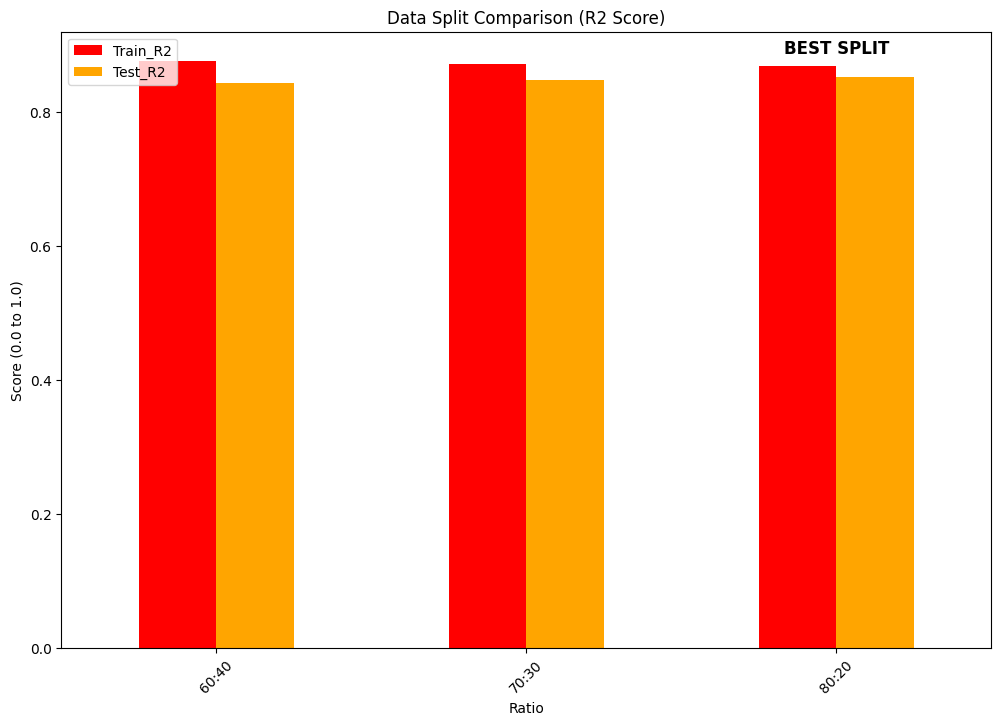

In [26]:
data = {
    'Ratio': ['60:40', '70:30', '80:20'],
    'Train_R2': train_scores,
    'Test_R2': test_scores,
}

df_results = pd.DataFrame(data)




ax = df_results.plot(
    x='Ratio',
    y=['Train_R2', 'Test_R2'],
    kind='bar',
    figsize=(12, 8),
    color=['red', 'orange']
)

plt.title('Data Split Comparison (R2 Score)')
plt.ylabel('Score (0.0 to 1.0)')
plt.xticks(rotation=45)

last_x = len(df_results) - 1

y_max = max(df_results['Train_R2'].iloc[-1], df_results['Test_R2'].iloc[-1])


plt.text(
    last_x,
    y_max + 0.02,
    "BEST SPLIT",
    ha='center',
    fontsize=12,
    fontweight='bold'
)

plt.show()

In [27]:
y_log = np.log1p(df['SalePrice']) 
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

fin_model = LinearRegression()
fin_model .fit(X_train, y_train_log)
y_pred_log=fin_model.predict(X_test)
# convert back
y_train_original = np.expm1(y_train_log)
y_test_original = np.expm1(y_test_log)
y_pred_original = np.expm1(y_pred_log)

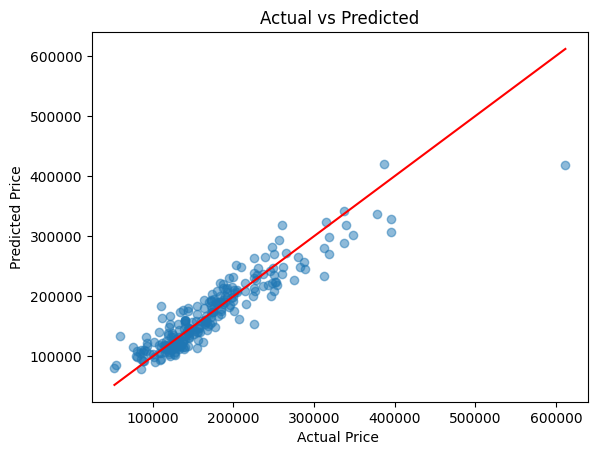

In [28]:
# linear regression
plt.scatter(y_test_original, y_pred_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], color='red')
plt.xlabel("Actual Price ")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
def get_user_input(features):
    user_data = {}

    print("\nEnter house details:\n")

    for feature in features:
        value = float(input(f"{feature}: "))  
        user_data[feature] = value

    return user_data
def predict_house_price(input_data):
    
    input_df = pd.DataFrame([input_data])
    
    
    input_df = input_df[X.columns]
    
  
    log_prediction = fin_model.predict(input_df)
    actual_price = np.expm1(log_prediction)[0]
    
    return actual_price
    
features = X.columns  

user_house = get_user_input(features)

estimated_value = predict_house_price(user_house)

print("\n Prediction Result")
print(f"Predicted Market Value: {estimated_value:,.2f}")


Enter house details:

